In [ ]:
import os
import sys

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
sys.path.append('../') 
os.getcwd()

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdchem
from rdkit.Chem import rdmolops, rdchem
from demo.ConfSeq import randomize_mol,get_ConfSeq_pair_from_mol,get_mol_from_ConfSeq_pair
import copy 
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence

from transformers import BartForConditionalGeneration, BartConfig
from collections import OrderedDict
import torch
from torch import nn

import numpy as np

In [ ]:
def rm_invalid_chirality(mol):
    mol = copy.deepcopy(mol)

    rings = rdmolops.GetSymmSSSR(mol)

    atom_in_rings_count = {}

    for ring in rings:
        for atom_idx in ring:
            if atom_idx not in atom_in_rings_count:
                atom_in_rings_count[atom_idx] = 0
            atom_in_rings_count[atom_idx] += 1

    atoms_in_3_rings = [atom for atom, count in atom_in_rings_count.items() if count == 3]

    for atom_idx in atoms_in_3_rings:
        atom = mol.GetAtomWithIdx(atom_idx)
        atom.SetChiralTag(rdchem.ChiralType.CHI_UNSPECIFIED)

    return mol


def neutralize_charge(mol):
    for atom in mol.GetAtoms():
        charge = atom.GetFormalCharge()
        num_h = atom.GetNumExplicitHs()

        if charge < 0 or (charge > 0 and num_h >= charge):
            has_opposite_neighbor = False

            for neighbor in atom.GetNeighbors():
                neighbor_charge = neighbor.GetFormalCharge()
                if neighbor_charge == -charge:
                    has_opposite_neighbor = True
                    break

            if not has_opposite_neighbor:  
                atom.SetFormalCharge(0)
                if charge > 0:
                    atom.SetNumExplicitHs(atom.GetNumExplicitHs() - charge)
                elif charge < 0:
                    atom.SetNumExplicitHs(atom.GetNumExplicitHs() - charge)

    Chem.SanitizeMol(mol)
    return mol


def get_ConfSeq(query_mol):

    if query_mol != None:
        try:
            query_mol = neutralize_charge(query_mol)
            query_mol = rm_invalid_chirality(query_mol)
            query_mol = randomize_mol(query_mol)
            Chem.MolToSmiles(query_mol)    
            query_mol = Chem.RenumberAtoms(query_mol, eval(query_mol.GetProp('_smilesAtomOutputOrder'))) 
            Chem.MolToSmiles(query_mol,canonical = False)
            query_mol = Chem.RenumberAtoms(query_mol, eval(query_mol.GetProp('_smilesAtomOutputOrder'))) 
            in_smiles,TD_smiles = get_ConfSeq_pair_from_mol(query_mol)
            TD_smiles = TD_smiles.replace('<180>','<-180>')
            
        except:
            in_smiles,TD_smiles = '',''            
    else:
        in_smiles,TD_smiles = '',''
        
    return TD_smiles

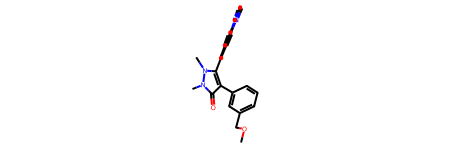

In [ ]:
mol = Chem.MolFromMolFile('./example/3kcf_JZO_C_3.mol')
mol

In [7]:
confseq = get_ConfSeq(mol)
confseq

'C O <111> | <-179> C <109> | <-26> c 1 c c c c ( <47> c 2 c ( <57> c 3 c c c 4 n c c n c 4 c 3 ) n ( C ) n ( C ) c 2 = O ) c 1'

In [ ]:
vocab = [chr(i) for i in range(33, 127)] 

for i in range(-180,180):
    vocab.append('<'+str(i)+'>')

vocab.append('<mask>')
vocab.append('<unk>')
vocab.append('<sos>')
vocab.append('<eos>')
vocab.append('<pad>')


config = BartConfig()

config.pad_token_id = vocab.index('<pad>')
config.eos_token_id = vocab.index('<eos>')
config.sos_token_id = vocab.index('<sos>')
config.forced_eos_token_id = None
config.encoder_layers = 6
config.encoder_attention_heads = 8
config.decoder_layers = 0
config.decoder_attention_heads = 0
config.d_model = 256
# config.share_embeddings = True
config.vocab_size = len(vocab)
# config.dropout=0.1        
# config.attention_dropout = 0.1
# config.classifier_dropout = 0.1
# config.num_hidden_layers = 6
# config.static_position_embeddings = True
# ############
# config.max_position_embeddings = 512
# config.activation_function = 'relu'

vocab_dict = {char: idx for idx, char in enumerate(vocab)}
bart = BartForConditionalGeneration(config = config )


class CustomBartEncoder(nn.Module):
    def __init__(self, bart):
        super().__init__()
    
        self.bart_model = bart 
        
    def forward(self, input_ids, attention_mask=None):
        outputs = self.bart_model.model.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

bart_encoder_model  = CustomBartEncoder(bart)
bart_encoder_model.eval()

CustomBartEncoder(
  (bart_model): BartForConditionalGeneration(
    (model): BartModel(
      (shared): BartScaledWordEmbedding(459, 256, padding_idx=458)
      (encoder): BartEncoder(
        (embed_tokens): BartScaledWordEmbedding(459, 256, padding_idx=458)
        (embed_positions): BartLearnedPositionalEmbedding(1026, 256)
        (layers): ModuleList(
          (0-5): 6 x BartEncoderLayer(
            (self_attn): BartSdpaAttention(
              (k_proj): Linear(in_features=256, out_features=256, bias=True)
              (v_proj): Linear(in_features=256, out_features=256, bias=True)
              (q_proj): Linear(in_features=256, out_features=256, bias=True)
              (out_proj): Linear(in_features=256, out_features=256, bias=True)
            )
            (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=256, out_features=4096, bias=True)
            (fc2): Linea

In [ ]:
class TensorDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.Tensor(self.data[idx]).long()

def collate_fn(batch):
    data = batch  
    padded_data = pad_sequence(data, batch_first=True, padding_value = vocab.index('<pad>')) 
    return padded_data


def mean_pooling(last_hidden_state, attention_mask):
    attention_mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size())
    sum_embeddings = (last_hidden_state * attention_mask).sum(dim=1)
    sum_mask = attention_mask.sum(dim=1)
    pooled_output = sum_embeddings / (sum_mask + 1e-8) 
    return pooled_output

In [10]:
def get_embedding_for_seq(model,confseq):
    int = [vocab_dict[i] for i in confseq.split(' ')] 
    int = torch.Tensor([int]).long()
    embed = bart_encoder_model(int).mean(dim=1).tolist()[0]
    return embed

In [ ]:
embedding_pubchem = np.load('./data/pubchem_embeddings/PubChem_embedding.npz')
embedding_pubchem = embedding_pubchem['arr_0']


print(embedding_pubchem.shape)

(97534269, 256)


In [ ]:
# Load the .npy file
pubchem_cid = np.load('./data/pubchem_embeddings/PubChem_CID.npy')

print(pubchem_cid.shape)  # If it's a numpy array

(97534269,)


In [ ]:
checkpoint = torch.load('./checkpoints/model_epoch_1.pth', map_location='cpu')  # 使用适当的设备

new_state_dict = OrderedDict()
for k, v in checkpoint.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v
    else:
        new_state_dict[k] = v

bart_encoder_model.load_state_dict(new_state_dict)

device = torch.device('cuda')

In [14]:
query_embed = get_embedding_for_seq(bart_encoder_model,confseq)

In [ ]:
import numpy as np
from tqdm import tqdm
  
batch_size = 100000  
num_total = embedding_pubchem.shape[0]

dists = np.empty(num_total, dtype=np.float32)  

for start in tqdm(range(0, num_total, batch_size), desc="calculate distance"):
    end = min(start + batch_size, num_total)
    batch = embedding_pubchem[start:end]  # shape: (batch_size, 256)
    dists[start:end] = np.linalg.norm(batch - query_embed, axis=1)


topk_indices = np.argsort(dists)[:200]
topk_values = dists[topk_indices]

print("Top-k indices:", topk_indices)
print("Distances", topk_values)


for i in topk_indices:
    print(pubchem_cid[i])

计算欧氏距离: 100%|██████████| 976/976 [02:48<00:00,  5.81it/s]


最近的20个样本索引: [43095138 43094997 66783731 43095142 73745054 43095140 43095139 43094665
 43094589 43094662 40838778 40839026 43095141 74641023 74640664 41975198
 25840757 74641277 21775332 75984491 85561294 43094995 43095067 40839184
 43094587 74640479 74639372 28071355 74638945 43094928 74640622 74639733
 54125378 74639373 36496713 81909100 25062239 43094994 74640562 28076347
 55542313 74641410 78440678 52889701 43094993 74638814 24056457 35598699
 36496708 74639411 20944696 55542274 17744716 81288871 43095063 86603656
 55542269 74640845 78043016 78043017 37410711 25950585 43094861 40839206
 74639631 75984492 12721951 77852503 74640045 68018722 31389737 77852586
 10713792 92182460 78042828 19673535 22344128 33655017 74640921 60442727
 21660118 43094992 74914636 43094518 52368714 51933321 92182515 43094586
 44521844  1767198 40838657 52891598 72028443 34873377 43094731 74639964
 43094996 30416219 74639799 55542311  9063345 37201140 40838607 40838547
 43094804 74639044 74639425 77852604 52